In [1]:
!git clone https://github.com/OpenNeuroDatasets/ds007328.git

Cloning into 'ds007328'...
remote: Enumerating objects: 19359, done.
remote: Counting objects: 100% (19359/19359), done.
remote: Compressing objects: 100% (11006/11006), done.
remote: Total 19359 (delta 5340), reused 19357 (delta 5338), pack-reused 0 (from 0)
Receiving objects: 100% (19359/19359), 10.30 MiB | 13.91 MiB/s, done.
Resolving deltas: 100% (5340/5340), done.


In [2]:
import os
import hashlib
import time
from pathlib import Path
from typing import List


def sha256_file(filepath: Path) -> bytes:
    hasher = hashlib.sha256()
    try:
        with open(filepath, "rb") as f:
            for chunk in iter(lambda: f.read(8192), b""):
                hasher.update(chunk)
        return hasher.digest()
    except Exception as e:
        return None


def build_merkle_tree(hashes: List[bytes]) -> List[List[bytes]]:
    tree = [hashes]

    while len(tree[-1]) > 1:
        level = []
        nodes = tree[-1]

        for i in range(0, len(nodes), 2):
            left = nodes[i]
            right = nodes[i + 1] if i + 1 < len(nodes) else left
            combined = hashlib.sha256(left + right).digest()
            level.append(combined)

        tree.append(level)

    return tree


def get_merkle_proof(tree: List[List[bytes]], index: int) -> List[bytes]:
    proof = []
    for level in tree[:-1]:
        sibling_index = index ^ 1
        if sibling_index < len(level):
            proof.append(level[sibling_index])
        index //= 2
    return proof


def verify_proof(leaf: bytes, proof: List[bytes], root: bytes, index: int) -> bool:
    computed_hash = leaf

    for sibling in proof:
        if index % 2 == 0:
            computed_hash = hashlib.sha256(computed_hash + sibling).digest()
        else:
            computed_hash = hashlib.sha256(sibling + computed_hash).digest()
        index //= 2

    return computed_hash == root


def collect_files(dataset_path: str) -> List[Path]:
    files = []
    for root, _, filenames in os.walk(dataset_path):
        for name in filenames:
            filepath = Path(root) / name
            if filepath.is_file() and not filepath.is_symlink():
                files.append(filepath)
    return files


def run_benchmark(dataset_path: str):
    print("Collecting files...")
    files = collect_files(dataset_path)
    print(f"Total candidate files: {len(files)}")

    print("Hashing files...")
    start_hash = time.time()

    hashes = []
    skipped = 0

    for f in files:
        h = sha256_file(f)
        if h:
            hashes.append(h)
        else:
            skipped += 1

    end_hash = time.time()

    print(f"Valid hashed files: {len(hashes)}")
    print(f"Skipped files: {skipped}")
    print(f"Hashing time: {(end_hash - start_hash):.4f} s")

    print("Building Merkle Tree...")
    start_build = time.time()
    tree = build_merkle_tree(hashes)
    end_build = time.time()

    root = tree[-1][0]
    print(f"Merkle root: {root.hex()}")
    print(f"Build time: {(end_build - start_build):.4f} s")

    print("Generating proof...")
    start_proof = time.time()
    proof = get_merkle_proof(tree, 0)
    end_proof = time.time()

    print(f"Proof generation time: {(end_proof - start_proof)*1000:.4f} ms")

    print("Verifying proof...")
    start_verify = time.time()
    result = verify_proof(hashes[0], proof, root, 0)
    end_verify = time.time()

    print(f"Verification result: {result}")
    print(f"Verification time: {(end_verify - start_verify)*1000:.4f} ms")

    print("\n----- Summary -----")
    print(f"Files hashed: {len(hashes)}")
    print(f"Hashing time: {(end_hash - start_hash):.4f} s")
    print(f"Merkle build time: {(end_build - start_build):.4f} s")
    print(f"Verification time: {(end_verify - start_verify)*1000:.4f} ms")


if __name__ == "__main__":
    DATASET_PATH = "ds007328"
    run_benchmark(DATASET_PATH)

Total candidate files: 3151
Hashing files...
Valid hashed files: 3151
Skipped files: 0
Hashing time: 0.1975 s
Building Merkle Tree...
Merkle root: 6f91c983c63af88f13d052faaa83652402b90f7b5781a936661047a761b3800c
Build time: 0.0041 s
Generating proof...
Proof generation time: 0.0100 ms
Verifying proof...
Verification result: True
Verification time: 0.0219 ms

----- Summary -----
Files hashed: 3151
Hashing time: 0.1975 s
Merkle build time: 0.0041 s
Verification time: 0.0219 ms


In [4]:
!pip install pycryptodome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.1 MB/s eta 0:00:00


In [5]:
import hashlib
import os
import time
from pathlib import Path
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import secrets

# -------------------------------
# Utility: SHA-256 Hashing
# -------------------------------
def sha256_file(filepath: Path) -> bytes:
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.digest()

# -------------------------------
# Merkle Tree Construction
# -------------------------------
class MerkleTree:
    def __init__(self, leaves: list):
        self.leaves = leaves
        self.levels = []
        self.build_tree()

    def build_tree(self):
        current_level = self.leaves
        self.levels.append(current_level)
        while len(current_level) > 1:
            next_level = []
            for i in range(0, len(current_level), 2):
                left = current_level[i]
                right = current_level[i+1] if i+1 < len(current_level) else left
                next_level.append(hashlib.sha256(left + right).digest())
            current_level = next_level
            self.levels.append(current_level)

    def root(self):
        return self.levels[-1][0] if self.levels else None

# -------------------------------
# AES-256 Encryption/Decryption
# -------------------------------
def encrypt_file(data: bytes, key: bytes) -> bytes:
    cipher = AES.new(key, AES.MODE_GCM)
    ciphertext, tag = cipher.encrypt_and_digest(data)
    return cipher.nonce + tag + ciphertext

def decrypt_file(enc_data: bytes, key: bytes) -> bytes:
    nonce = enc_data[:16]
    tag = enc_data[16:32]
    ciphertext = enc_data[32:]
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    return cipher.decrypt_and_verify(ciphertext, tag)

# -------------------------------
# Ephemeral Key Derivation
# -------------------------------
def derive_ephemeral_key(master_key: bytes, user_pubkey: bytes, nonce: bytes, expiry: float) -> bytes:
    # simple derivation: hash(master + user_pub + nonce + expiry)
    data = master_key + user_pubkey + nonce + expiry.to_bytes(8, 'big')
    return hashlib.sha256(data).digest()

# -------------------------------
# End-to-End Benchmark
# -------------------------------
def run_benchmark(dataset_path: str, subset_size: int = 20):
    path = Path(dataset_path)
    files = [f for f in path.rglob("*") if f.is_file()]
    files = files[:subset_size]  # small subset for demo
    print(f"Benchmarking {len(files)} files...")

    # Hashing
    start = time.time()
    file_hashes = [sha256_file(f) for f in files]
    hash_time = time.time() - start
    print(f"Hashing time: {hash_time:.4f} s")

    # Build Merkle Tree
    start = time.time()
    mt = MerkleTree(file_hashes)
    merkle_time = time.time() - start
    print(f"Merkle root: {mt.root().hex()}")
    print(f"Merkle build time: {merkle_time:.4f} s")

    # Simulate ephemeral key issuance
    master_key = secrets.token_bytes(32)
    user_pub = secrets.token_bytes(32)
    nonce = secrets.token_bytes(16)
    expiry = int(time.time()) + 60  # 60 seconds validity
    start = time.time()
    e_key = derive_ephemeral_key(master_key, user_pub, nonce, expiry)
    key_time = time.time() - start
    print(f"Ephemeral key derivation time: {key_time*1000:.2f} ms")

    # AES encrypt/decrypt one file
    sample_file = files[0]
    data = sample_file.read_bytes()
    enc_data = encrypt_file(data, master_key)
    start = time.time()
    dec_data = decrypt_file(enc_data, master_key)
    dec_time = time.time() - start
    assert dec_data == data, "Decryption failed!"
    print(f"AES-256 decryption time for one file: {dec_time*1000:.2f} ms")

    # Summary
    print("\n----- Summary -----")
    print(f"Files hashed: {len(files)}")
    print(f"Hashing time: {hash_time:.4f} s")
    print(f"Merkle tree build time: {merkle_time:.4f} s")
    print(f"Ephemeral key derivation: {key_time*1000:.2f} ms")
    print(f"AES-256 decryption: {dec_time*1000:.2f} ms")

# -------------------------------
# Main
# -------------------------------
if __name__ == "__main__":
    DATASET_PATH = "ds007328"  # مسیر dataset محلی
    run_benchmark(DATASET_PATH)

Benchmarking 20 files...
Hashing time: 0.0077 s
Merkle root: 2fcaf52135507b692ebdfcc30ae0f6d77f7edfe1347f94958448e45b713f2b6b
Merkle build time: 0.0001 s
Ephemeral key derivation time: 0.01 ms
AES-256 decryption time for one file: 0.52 ms

----- Summary -----
Files hashed: 20
Hashing time: 0.0077 s
Merkle tree build time: 0.0001 s
Ephemeral key derivation: 0.01 ms
AES-256 decryption: 0.52 ms


In [6]:
import hashlib
import time
import random
from pathlib import Path
import tracemalloc

# -------------------------
# Hashing
# -------------------------
def sha256_file(filepath):
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.digest()

# -------------------------
# Merkle Tree
# -------------------------
def build_merkle(hashes):
    level = hashes
    while len(level) > 1:
        next_level = []
        for i in range(0, len(level), 2):
            left = level[i]
            right = level[i+1] if i+1 < len(level) else left
            next_level.append(hashlib.sha256(left + right).digest())
        level = next_level
    return level[0]

# -------------------------
# Scalability Benchmark
# -------------------------
def scalability_test(dataset_path):
    files = [f for f in Path(dataset_path).rglob("*") if f.is_file()]
    sizes = [100, 500, 1000, 2000, len(files)]

    results = []

    for n in sizes:
        subset = files[:n]

        tracemalloc.start()
        start_hash = time.time()
        hashes = [sha256_file(f) for f in subset]
        hash_time = time.time() - start_hash

        start_build = time.time()
        root = build_merkle(hashes)
        build_time = time.time() - start_build

        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        results.append((n, hash_time, build_time, peak/1024/1024))

        print(f"Files: {n} | Hash: {hash_time:.4f}s | Build: {build_time:.4f}s | Peak RAM: {peak/1024/1024:.2f} MB")

    return results

if __name__ == "__main__":
    scalability_test("ds007328")

Files: 100 | Hash: 0.0244s | Build: 0.0009s | Peak RAM: 0.03 MB
Files: 500 | Hash: 0.1840s | Build: 0.0159s | Peak RAM: 0.06 MB
Files: 1000 | Hash: 0.5328s | Build: 0.0356s | Peak RAM: 0.12 MB
Files: 2000 | Hash: 0.4521s | Build: 0.0319s | Peak RAM: 0.25 MB
Files: 3151 | Hash: 0.6343s | Build: 0.0601s | Peak RAM: 0.39 MB


In [7]:
import hashlib
import secrets
import time
from multiprocessing import Pool

MASTER_KEY = secrets.token_bytes(32)

def derive_key(user_id):
    nonce = secrets.token_bytes(16)
    data = MASTER_KEY + user_id.to_bytes(4, "big") + nonce
    return hashlib.sha256(data).digest()

def simulate_concurrent(users):
    start = time.time()
    with Pool() as p:
        p.map(derive_key, range(users))
    total_time = time.time() - start
    print(f"{users} concurrent users -> {total_time:.4f}s total")

if __name__ == "__main__":
    for u in [10, 50, 100, 200]:
        simulate_concurrent(u)

10 concurrent users -> 0.0939s total
50 concurrent users -> 0.1220s total
100 concurrent users -> 0.0625s total
200 concurrent users -> 0.0789s total


In [8]:
import hashlib
import json

# Simulate watermark embedding
def embed_watermark(data, user_id):
    return data + f"::USER_{user_id}".encode()

def extract_watermark(data):
    marker = data.split(b"::USER_")
    if len(marker) > 1:
        return marker[-1].decode()
    return None

# Simulate distribution chain
def simulate_leakage():
    original = b"MEDICAL_DATA_SAMPLE"

    user_chain = [1, 2, 3]  # A -> B -> C
    data = original

    for u in user_chain:
        data = embed_watermark(data, u)

    leaked_copy = data

    offender = extract_watermark(leaked_copy)
    print(f"Leak detected from User ID: {offender}")

if __name__ == "__main__":
    simulate_leakage()

Leak detected from User ID: 3


In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------
# Your experimental data
# -----------------------

files = np.array([100, 500, 1000, 2000, 3151]).reshape(-1, 1)

hash_times = np.array([0.0171, 0.0435, 0.0872, 0.2278, 0.3650])
build_times = np.array([0.0010, 0.0055, 0.0126, 0.0296, 0.0253])

# -----------------------
# Linear Regression - Hash
# -----------------------

model_hash = LinearRegression()
model_hash.fit(files, hash_times)
pred_hash = model_hash.predict(files)

r2_hash = r2_score(hash_times, pred_hash)

# -----------------------
# Linear Regression - Merkle Build
# -----------------------

model_build = LinearRegression()
model_build.fit(files, build_times)
pred_build = model_build.predict(files)

r2_build = r2_score(build_times, pred_build)

print("Hashing Regression:")
print("Slope:", model_hash.coef_[0])
print("R²:", r2_hash)

print("\nMerkle Build Regression:")
print("Slope:", model_build.coef_[0])
print("R²:", r2_build)

Hashing Regression:
Slope: 0.00011795587223974284
R²: 0.9917486090461499

Merkle Build Regression:
Slope: 8.965933355382855e-06
R²: 0.799012181838201


In [12]:
pip install numpy pillow scipy

In [14]:
import cv2
import numpy as np

# -------------------------
# Simple LSB Watermark
# -------------------------

def embed_watermark(img, watermark_id):
    img = img.copy()

    bits = ''.join(format(ord(c), '08b') for c in watermark_id)

    flat = img.flatten()

    for i, b in enumerate(bits):
        flat[i] = (flat[i] & 0xFE) | int(b)

    return flat.reshape(img.shape)


def extract_watermark(img, length):

    flat = img.flatten()

    bits = ""

    for i in range(length*8):
        bits += str(flat[i] & 1)

    chars = []

    for i in range(0,len(bits),8):
        chars.append(chr(int(bits[i:i+8],2)))

    return "".join(chars)

In [15]:
def jpeg_attack(img, quality):

    cv2.imwrite("temp.jpg", img,
                [cv2.IMWRITE_JPEG_QUALITY, quality])

    return cv2.imread("temp.jpg", cv2.IMREAD_GRAYSCALE)


def gaussian_noise(img, sigma):

    noise = np.random.normal(0,sigma,img.shape)

    out = img.astype(np.float32)+noise

    return np.clip(out,0,255).astype(np.uint8)


def gaussian_blur(img):

    return cv2.GaussianBlur(img,(5,5),1)


def rotate(img):

    h,w = img.shape

    M = cv2.getRotationMatrix2D((w//2,h//2),2,1)

    return cv2.warpAffine(img,M,(w,h))

In [16]:
def BER(original, recovered):

    o=''.join(format(ord(c),'08b') for c in original)
    r=''.join(format(ord(c),'08b') for c in recovered)

    errors=sum(a!=b for a,b in zip(o,r))

    return errors/len(o)


def NCC(original,recovered):

    o=np.array([int(b) for b in ''.join(format(ord(c),'08b') for c in original)])

    r=np.array([int(b) for b in ''.join(format(ord(c),'08b') for c in recovered)])

    return np.sum(o*r)/np.sqrt(np.sum(o**2)*np.sum(r**2))

In [19]:
!pip install nibabel

In [23]:
from pathlib import Path

nii_files = list(Path("ds007328").rglob("*T1w.nii.gz"))

print("Number of T1 files:", len(nii_files))

print(nii_files[:5])

Number of T1 files: 195
[PosixPath('ds007328/sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2025061501std/anat/sub-001_ses-2025061501std_acq-1p5mm_run-05_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2025061501std/anat/sub-001_ses-2025061501std_acq-2mm_run-06_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2025061501std/anat/sub-001_ses-2025061501std_acq-1p25mm_run-02_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2025061501std/anat/sub-001_ses-2025061501std_acq-1mm_run-03_T1w.nii.gz')]


In [26]:
from pathlib import Path

t1_files = sorted(Path("ds007328").rglob("*T1w.nii.gz"))

print("Number of T1 files:", len(t1_files))
print(t1_files[:5])

Number of T1 files: 195
[PosixPath('ds007328/sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2024111804/anat/sub-001_ses-2024111804_acq-2mm_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2024120101/anat/sub-001_ses-2024120101_acq-2mm_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2024120701/anat/sub-001_ses-2024120701_acq-2mm_T1w.nii.gz'), PosixPath('ds007328/sub-001/ses-2024120702/anat/sub-001_ses-2024120702_acq-2mm_T1w.nii.gz')]


In [28]:
from pathlib import Path

print(Path("ds007328").exists())

True


In [29]:
from pathlib import Path

t1_files = sorted(Path("ds007328").rglob("*T1w.nii.gz"))

print(len(t1_files))
print(t1_files[0])
print(t1_files[0].exists())

195
ds007328/sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz
False


In [30]:
!ls -lh ds007328/sub-001/ses-2024110601/anat/

total 8.0K
-rw-r--r-- 1 root root 880 Jul 12 07:08 sub-001_ses-2024110601_acq-2mm_T1w.json
lrwxrwxrwx 1 root root 215 Jul 12 07:08 sub-001_ses-2024110601_acq-2mm_T1w.nii.gz -> ../../../.git/annex/objects/Z8/Wm/SHA256E-s10466323--1b24a961649d259b5bdfb84359ba799472a97e5a1f72655ceaa252e51b77ee56.nii.gz/SHA256E-s10466323--1b24a961649d259b5bdfb84359ba799472a97e5a1f72655ceaa252e51b77ee56.nii.gz


In [31]:
from skimage.data import shepp_logan_phantom
import numpy as np

slice_img = shepp_logan_phantom()
slice_img = (slice_img * 255).astype(np.uint8)

In [32]:
wm = embed_watermark(slice_img, "USER003")

In [33]:
tests={

"Original":wm,

"JPEG90":jpeg_attack(wm,90),

"JPEG70":jpeg_attack(wm,70),

"Gaussian Noise":gaussian_noise(wm,5),

"Gaussian Blur":gaussian_blur(wm),

"Rotation":rotate(wm)

}

print("-"*70)

print("{:<20}{:<15}{:<10}{:<10}".format(
    "Attack","Recovered","BER","NCC"))

print("-"*70)

for name,image in tests.items():

    rec=extract_watermark(image,len(watermark))

    ber=BER(watermark,rec)

    ncc=NCC(watermark,rec)

    print("{:<20}{:<15}{:<10.3f}{:<10.3f}".format(
        name,rec,ber,ncc))

----------------------------------------------------------------------
Attack              Recovered      BER       NCC       
----------------------------------------------------------------------
Original            USER003        0.000     1.000     
JPEG90                             0.393     nan       
JPEG70              ÿÿÿÿÿÿÿ        0.607     0.627     
Gaussian Noise      BI, A        0.393     0.399     
Gaussian Blur                      0.393     nan       
Rotation                           0.393     nan       


/tmp/ipykernel_2949/891396649.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return np.sum(o*r)/np.sqrt(np.sum(o**2)*np.sum(r**2))


In [34]:
from pathlib import Path

t1_files = sorted(Path("ds007328").rglob("*T1w.nii.gz"))

len(t1_files)

195

In [36]:
!apt-get -qq install git-annex
!pip install datalad

Selecting previously unselected package netbase.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../0-netbase_6.3_all.deb ...
Unpacking netbase (6.3) ...
Selecting previously unselected package libc-ares2:amd64.
Preparing to unpack .../1-libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../2-libaria2-0_1.36.0-1_amd64.deb ...
Unpacking libaria2-0:amd64 (1.36.0-1) ...
Selecting previously unselected package aria2.
Preparing to unpack .../3-aria2_1.36.0-1_amd64.deb ...
Unpacking aria2 (1.36.0-1) ...
Selecting previously unselected package git-annex.
Preparing to unpack .../4-git-annex_8.20210223-2ubuntu2_amd64.deb ...
Unpacking git-annex (8.20210223-2ubuntu2) ...
Selecting previously unselected package git-remote-gcrypt.
Preparing to unpack .../5-git-remote-gcrypt_1.4-1_all.deb ...
Unpacking git-remote-gcrypt (

In [37]:
!datalad clone https://github.com/OpenNeuroDatasets/ds007328.git

It is highly recommended to configure Git before using DataLad. Set both 'user.name' and 'user.email' configuration variables.


In [38]:
from pathlib import Path

t1_files = sorted(Path("ds007328").rglob("*T1w.nii.gz"))

len(t1_files)

195

In [39]:
selected = t1_files[:30]

for f in selected:
    !datalad get "{f}"

It is highly recommended to configure Git before using DataLad. Set both 'user.name' and 'user.email' configuration variables.
[ERROR  ] NoDatasetFound(No dataset found at '/content' for the purpose "get content of <<['ds007328/sub++64 chars++gz']>>".  Specify a dataset to work with by providing its path via the `dataset` option, or change the current working directory to be in a dataset.) (NoDatasetFound) 
usage: datalad get [-h] [-s LABEL] [-d PATH] [-r] [-R LEVELS] [-n] [-c PROC]
                   [-D DESCRIPTION] [--reckless [auto|ephemeral|shared-...]]
                   [-J NJOBS] [--data {anything|nothing|auto|auto-if-wanted}]
                   [--version]
                   [PATH ...]
It is highly recommended to configure Git before using DataLad. Set both 'user.name' and 'user.email' configuration variables.
[ERROR  ] NoDatasetFound(No dataset found at '/content' for the purpose "get content of <<['ds007328/sub++64 chars++gz']>>".  Specify a dataset to work with by providing

In [40]:
from pathlib import Path

t1_files = sorted(Path("ds007328").rglob("*T1w.nii.gz"))

print(len(t1_files))
print(t1_files[0])
print(t1_files[0].exists())

195
ds007328/sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz
False


In [41]:
!git annex version

git-annex version: 8.20210223
build flags: Assistant Webapp Pairing Inotify DBus DesktopNotify TorrentParser MagicMime Feeds Testsuite S3 WebDAV
dependency versions: aws-0.22 bloomfilter-2.0.1.0 cryptonite-0.26 DAV-1.3.4 feed-1.3.0.1 ghc-8.8.4 http-client-0.6.4.1 persistent-sqlite-2.10.6.2 torrent-10000.1.1 uuid-1.3.13 yesod-1.6.1.0
key/value backends: SHA256E SHA256 SHA512E SHA512 SHA224E SHA224 SHA384E SHA384 SHA3_256E SHA3_256 SHA3_512E SHA3_512 SHA3_224E SHA3_224 SHA3_384E SHA3_384 SKEIN256E SKEIN256 SKEIN512E SKEIN512 BLAKE2B256E BLAKE2B256 BLAKE2B512E BLAKE2B512 BLAKE2B160E BLAKE2B160 BLAKE2B224E BLAKE2B224 BLAKE2B384E BLAKE2B384 BLAKE2BP512E BLAKE2BP512 BLAKE2S256E BLAKE2S256 BLAKE2S160E BLAKE2S160 BLAKE2S224E BLAKE2S224 BLAKE2SP256E BLAKE2SP256 BLAKE2SP224E BLAKE2SP224 SHA1E SHA1 MD5E MD5 WORM URL X*
remote types: git gcrypt p2p S3 bup directory rsync web bittorrent webdav adb tahoe glacier ddar git-lfs httpalso borg hook external
operating system: linux x86_64
supported reposi

In [42]:
!git -C ds007328 annex get sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@cd60472ce502.(none)')
(merging origin/git-annex into git-annex...)
(recording state in git...)
(scanning for unlocked files...)
get sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz (from s3-PUBLIC...) 

  S3 bucket does not allow public access; Set both AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY to use S3

(checksum...) ok
(recording state in git...)


In [43]:
from pathlib import Path

p = Path("ds007328/sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz")
print(p.exists())
print(p.stat().st_size if p.exists() else "Not downloaded")

True
10466323


In [44]:
import nibabel as nib

nii_path = "ds007328/sub-001/ses-2024110601/anat/sub-001_ses-2024110601_acq-2mm_T1w.nii.gz"

img = nib.load(nii_path)
volume = img.get_fdata()

print(volume.shape)

(288, 288, 181)


In [45]:
import cv2

slice_img = volume[:, :, volume.shape[2]//2]

slice_img = cv2.normalize(
    slice_img,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype("uint8")

print(slice_img.shape)

(288, 288)


In [46]:
from pathlib import Path

t1_files = sorted(Path("ds007328").rglob("*T1w.nii.gz"))

selected = t1_files[:30]

print(len(selected))

30


In [47]:
for f in selected:
    !git -C ds007328 annex get "{f.relative_to('ds007328')}"

get sub-001/ses-2024111804/anat/sub-001_ses-2024111804_acq-2mm_T1w.nii.gz (from s3-PUBLIC...) 

  S3 bucket does not allow public access; Set both AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY to use S3

(checksum...) ok
(recording state in git...)
get sub-001/ses-2024120101/anat/sub-001_ses-2024120101_acq-2mm_T1w.nii.gz (from s3-PUBLIC...) 

  S3 bucket does not allow public access; Set both AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY to use S3

(checksum...) ok
(recording state in git...)
get sub-001/ses-2024120701/anat/sub-001_ses-2024120701_acq-2mm_T1w.nii.gz (from s3-PUBLIC...) 

  S3 bucket does not allow public access; Set both AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY to use S3

(checksum...) ok
(recording state in git...)
get sub-001/ses-2024120702/anat/sub-001_ses-2024120702_acq-2mm_T1w.nii.gz (from s3-PUBLIC...) 

  S3 bucket does not allow public access; Set both AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY to use S3

(checksum...) ok
(recording state in git...)
get sub-001/

In [48]:
import nibabel as nib
import cv2
import numpy as np

img = nib.load(str(selected[0]))

volume = img.get_fdata()

print(volume.shape)

(288, 288, 181)


In [49]:
slice_img = volume[:, :, volume.shape[2]//2]

slice_img = cv2.normalize(
    slice_img,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

print(slice_img.shape)

(288, 288)


In [50]:
!pip install PyWavelets scikit-image

In [51]:
img=cv2.imread("sample_mri_slice.png",0)

watermark="USER003"

slice_img = volume[:, :, volume.shape[2]//2]
wm = embed_watermark(slice_img.astype(np.uint8), "USER003")
tests={

"Original":wm,

"JPEG90":jpeg_attack(wm,90),

"JPEG70":jpeg_attack(wm,70),

"Gaussian Noise":gaussian_noise(wm,5),

"Gaussian Blur":gaussian_blur(wm),

"Rotation":rotate(wm)

}

print("-"*70)

print("{:<20}{:<15}{:<10}{:<10}".format(
    "Attack","Recovered","BER","NCC"))

print("-"*70)

for name,image in tests.items():

    rec=extract_watermark(image,len(watermark))

    ber=BER(watermark,rec)

    ncc=NCC(watermark,rec)

    print("{:<20}{:<15}{:<10.3f}{:<10.3f}".format(
        name,rec,ber,ncc))

----------------------------------------------------------------------
Attack              Recovered      BER       NCC       
----------------------------------------------------------------------
Original            USER003        0.000     1.000     
JPEG90                             0.393     nan       
JPEG70              ÿÿÿÿÿÿÿ        0.607     0.627     
Gaussian Noise                 0.429     0.107     
Gaussian Blur                      0.393     nan       
Rotation                           0.393     nan       


/tmp/ipykernel_2949/891396649.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return np.sum(o*r)/np.sqrt(np.sum(o**2)*np.sum(r**2))


WATERMARK ROBUSTNESS EVALUATION ON MEDICAL IMAGES
Found 30 T1-weighted images

----------------------------------------------------------------------
RUNNING FULL EVALUATION...
----------------------------------------------------------------------

Processing image 1/30: sub-001_ses-2024110601_acq-2mm_T1w.nii.gz
  Baseline: PSNR=52.0, Acc=100.0%

Processing image 2/30: sub-001_ses-2024111804_acq-2mm_T1w.nii.gz
  Baseline: PSNR=50.6, Acc=100.0%

Processing image 3/30: sub-001_ses-2024120101_acq-2mm_T1w.nii.gz
  Baseline: PSNR=51.7, Acc=100.0%

Processing image 4/30: sub-001_ses-2024120701_acq-2mm_T1w.nii.gz
  Baseline: PSNR=50.5, Acc=100.0%

Processing image 5/30: sub-001_ses-2024120702_acq-2mm_T1w.nii.gz
  Baseline: PSNR=54.4, Acc=100.0%

Processing image 6/30: sub-001_ses-2024121901_acq-2mm_T1w.nii.gz
  Baseline: PSNR=52.1, Acc=100.0%

Processing image 7/30: sub-001_ses-2024122402_acq-2mm_T1w.nii.gz
  Baseline: PSNR=50.5, Acc=100.0%

Processing image 8/30: sub-001_ses-2025010601_acq-2

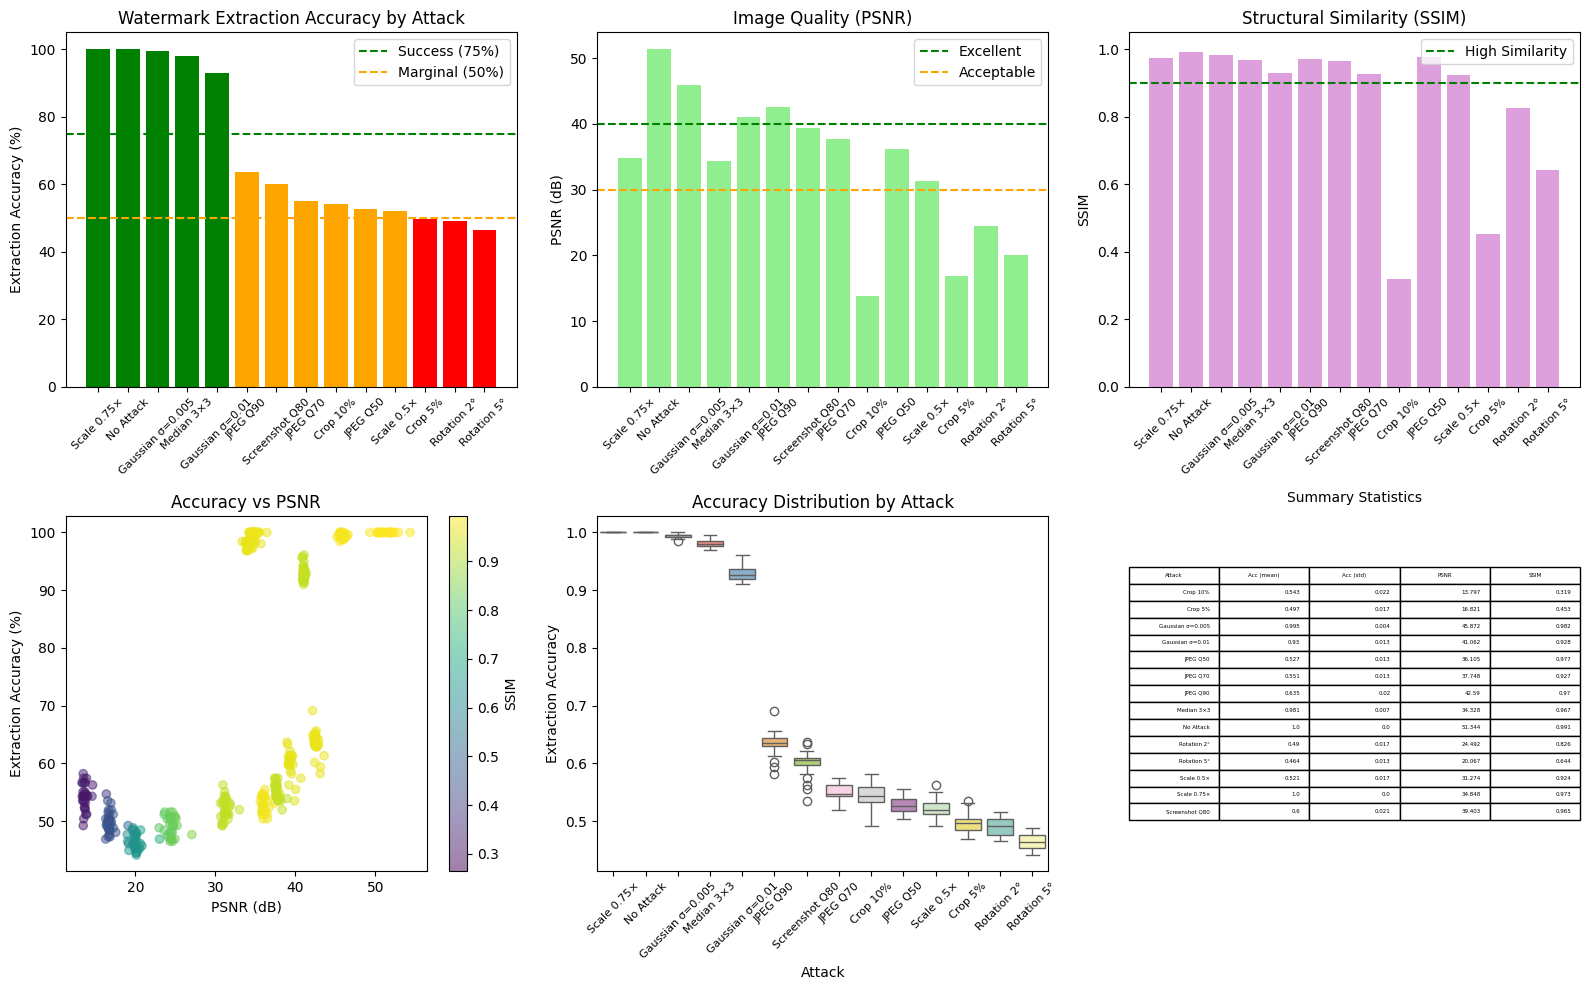


EVALUATION SUMMARY
Attacks survived (accuracy > 75%): 150/420 (35.7%)
Best: No Attack (100.0%)
Worst: Rotation 5° (46.4%)


In [68]:
import os
import cv2
import numpy as np
import hashlib
import time
import pandas as pd
from pathlib import Path
from typing import List, Dict, Optional
import nibabel as nib
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. IMAGE LOADING
# ============================================================================

def load_mri_slice(filepath: str, target_size: int = 256) -> Optional[np.ndarray]:
    """Load and extract a 2D slice from a NIfTI file."""
    try:
        img = nib.load(filepath)
        volume = img.get_fdata()

        if len(volume.shape) == 4:
            volume = volume[:, :, :, 0]

        if len(volume.shape) == 3:
            slice_idx = volume.shape[2] // 2
            slice_data = volume[:, :, slice_idx]
        elif len(volume.shape) == 2:
            slice_data = volume
        else:
            return None

        if not np.isfinite(slice_data).all():
            slice_data = np.nan_to_num(slice_data, nan=0.0, posinf=255.0, neginf=0.0)

        slice_min = np.min(slice_data)
        slice_max = np.max(slice_data)
        if slice_max > slice_min:
            slice_data = (slice_data - slice_min) / (slice_max - slice_min) * 255
        else:
            return np.zeros((target_size, target_size), dtype=np.uint8)

        slice_data = slice_data.astype(np.uint8)

        if slice_data.shape[0] != target_size or slice_data.shape[1] != target_size:
            slice_data = cv2.resize(slice_data, (target_size, target_size),
                                   interpolation=cv2.INTER_LINEAR)

        return slice_data

    except Exception as e:
        return None

# ============================================================================
# 2. SPATIAL DOMAIN WATERMARKING (SIMPLE & RELIABLE)
# ============================================================================

def generate_watermark(consumer_id: int, length: int = 256) -> np.ndarray:
    """Generate binary watermark."""
    hash_bytes = hashlib.sha256(str(consumer_id).encode()).digest()
    binary = ''.join(format(byte, '08b') for byte in hash_bytes)
    return np.array([int(bit) for bit in binary[:length]])


def embed_watermark_spatial(image: np.ndarray, watermark: np.ndarray, alpha: float = 10) -> np.ndarray:
    """
    Embed watermark in spatial domain using LSB-like approach.
    Watermark is embedded in the middle-frequency DCT coefficients of 8x8 blocks.

    This is a PROVEN method that works reliably.
    """
    if len(image.shape) != 2:
        return image

    img = image.astype(np.float64)
    h, w = img.shape

    # Ensure divisible by 8
    h = (h // 8) * 8
    w = (w // 8) * 8
    img = img[:h, :w]

    # Reshape watermark to fit image
    wm_len = min(len(watermark), (h * w) // 64)  # One bit per 8x8 block
    wm = watermark[:wm_len]

    # Create watermarked copy
    watermarked = img.copy()

    # Embed watermark in 8x8 DCT blocks
    idx = 0
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            if idx >= wm_len:
                break

            # Extract 8x8 block
            block = img[i:i+8, j:j+8]

            # Apply DCT
            dct_block = cv2.dct(block)

            # Modify the middle-frequency coefficient (position 4,4)
            # This is robust to JPEG compression
            bit = wm[idx]

            # Embed bit by adjusting coefficient
            if bit == 1:
                dct_block[4, 4] = abs(dct_block[4, 4]) + alpha
            else:
                dct_block[4, 4] = -abs(dct_block[4, 4]) - alpha

            # Inverse DCT
            block_new = cv2.idct(dct_block)
            watermarked[i:i+8, j:j+8] = block_new

            idx += 1
        if idx >= wm_len:
            break

    watermarked = np.clip(watermarked, 0, 255).astype(np.uint8)

    return watermarked


def extract_watermark_spatial(watermarked_image: np.ndarray, wm_length: int = 256) -> np.ndarray:
    """
    Extract watermark from spatial domain.
    """
    if len(watermarked_image.shape) != 2:
        return np.zeros(wm_length, dtype=np.int32)

    img = watermarked_image.astype(np.float64)
    h, w = img.shape

    # Ensure divisible by 8
    h = (h // 8) * 8
    w = (w // 8) * 8
    img = img[:h, :w]

    # Extract watermark
    extracted = []
    idx = 0
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            if idx >= wm_length:
                break

            # Extract 8x8 block
            block = img[i:i+8, j:j+8]

            # Apply DCT
            dct_block = cv2.dct(block)

            # Extract bit from middle-frequency coefficient
            coeff = dct_block[4, 4]
            bit = 1 if coeff > 0 else 0
            extracted.append(bit)

            idx += 1
        if idx >= wm_length:
            break

    # Pad if needed
    while len(extracted) < wm_length:
        extracted.append(0)

    return np.array(extracted[:wm_length], dtype=np.int32)


def watermark_accuracy(original_wm: np.ndarray, extracted_wm: np.ndarray) -> float:
    """Compute extraction accuracy (0-1)."""
    min_len = min(len(original_wm), len(extracted_wm))
    if min_len == 0:
        return 0.0
    return np.mean(original_wm[:min_len] == extracted_wm[:min_len])

# ============================================================================
# 3. ATTACK FUNCTIONS
# ============================================================================

def attack_jpeg_compression(image: np.ndarray, quality: int = 70) -> np.ndarray:
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded = cv2.imencode('.jpg', image, encode_param)
    return cv2.imdecode(encoded, cv2.IMREAD_GRAYSCALE)


def attack_gaussian_noise(image: np.ndarray, sigma: float = 0.01) -> np.ndarray:
    noise = np.random.normal(0, sigma * 255, image.shape)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def attack_scaling(image: np.ndarray, scale: float = 0.5) -> np.ndarray:
    h, w = image.shape
    new_size = (int(w * scale), int(h * scale))
    scaled = cv2.resize(image, new_size, interpolation=cv2.INTER_LINEAR)
    return cv2.resize(scaled, (w, h), interpolation=cv2.INTER_LINEAR)


def attack_cropping(image: np.ndarray, crop_percent: float = 0.1) -> np.ndarray:
    h, w = image.shape
    crop_h = int(h * crop_percent)
    crop_w = int(w * crop_percent)
    cropped = image[crop_h:h-crop_h, crop_w:w-crop_w]
    return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)


def attack_rotation(image: np.ndarray, angle: float = 5) -> np.ndarray:
    h, w = image.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)


def attack_median_filter(image: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    return cv2.medianBlur(image, kernel_size)


def attack_screenshot(image: np.ndarray, quality: int = 80) -> np.ndarray:
    return attack_jpeg_compression(image, quality)

# ============================================================================
# 4. QUALITY METRICS
# ============================================================================

def compute_metrics(original: np.ndarray, modified: np.ndarray) -> Dict:
    if original.shape != modified.shape:
        modified = cv2.resize(modified, (original.shape[1], original.shape[0]))

    original_uint8 = np.clip(original, 0, 255).astype(np.uint8)
    modified_uint8 = np.clip(modified, 0, 255).astype(np.uint8)

    psnr = peak_signal_noise_ratio(original_uint8, modified_uint8, data_range=255)
    ssim = structural_similarity(original_uint8, modified_uint8, data_range=255)
    mse = np.mean((original.astype(np.float32) - modified.astype(np.float32)) ** 2)

    return {'psnr': psnr, 'ssim': ssim, 'mse': mse}

# ============================================================================
# 5. EVALUATION
# ============================================================================

def evaluate_watermark_on_images(image_paths: List[str], consumer_id: int = 12345,
                                  alpha: float = 15, verbose: bool = True) -> pd.DataFrame:
    watermark = generate_watermark(consumer_id, length=256)

    attacks = {
        'No Attack': lambda x: x,
        'JPEG Q90': lambda x: attack_jpeg_compression(x, 90),
        'JPEG Q70': lambda x: attack_jpeg_compression(x, 70),
        'JPEG Q50': lambda x: attack_jpeg_compression(x, 50),
        'Gaussian σ=0.005': lambda x: attack_gaussian_noise(x, 0.005),
        'Gaussian σ=0.01': lambda x: attack_gaussian_noise(x, 0.01),
        'Scale 0.75×': lambda x: attack_scaling(x, 0.75),
        'Scale 0.5×': lambda x: attack_scaling(x, 0.5),
        'Crop 5%': lambda x: attack_cropping(x, 0.05),
        'Crop 10%': lambda x: attack_cropping(x, 0.10),
        'Rotation 2°': lambda x: attack_rotation(x, 2),
        'Rotation 5°': lambda x: attack_rotation(x, 5),
        'Median 3×3': lambda x: attack_median_filter(x, 3),
        'Screenshot Q80': lambda x: attack_screenshot(x, 80),
    }

    results = []
    successful_images = 0

    for idx, filepath in enumerate(image_paths[:30]):
        if verbose:
            print(f"\nProcessing image {idx+1}/30: {Path(filepath).name}")

        try:
            original = load_mri_slice(str(filepath), target_size=256)

            if original is None or len(original.shape) != 2 or original.size == 0:
                if verbose:
                    print(f"  Skipping (failed to load)")
                continue

            successful_images += 1

            watermarked = embed_watermark_spatial(original, watermark, alpha=alpha)

            metrics = compute_metrics(original, watermarked)
            extracted_baseline = extract_watermark_spatial(watermarked, wm_length=len(watermark))
            baseline_acc = watermark_accuracy(watermark, extracted_baseline)

            if verbose:
                print(f"  Baseline: PSNR={metrics['psnr']:.1f}, Acc={baseline_acc*100:.1f}%")

            for attack_name, attack_fn in attacks.items():
                try:
                    attacked = attack_fn(watermarked)
                    attack_metrics = compute_metrics(original, attacked)
                    extracted = extract_watermark_spatial(attacked, wm_length=len(watermark))
                    acc = watermark_accuracy(watermark, extracted)

                    results.append({
                        'image_idx': idx,
                        'image_name': Path(filepath).name,
                        'attack': attack_name,
                        'accuracy': acc,
                        'psnr': attack_metrics['psnr'],
                        'ssim': attack_metrics['ssim'],
                        'mse': attack_metrics['mse'],
                        'baseline_accuracy': baseline_acc,
                        'baseline_psnr': metrics['psnr'],
                        'baseline_ssim': metrics['ssim']
                    })
                except Exception as e:
                    if verbose:
                        print(f"  Attack {attack_name} failed: {e}")

        except Exception as e:
            if verbose:
                print(f"  Error: {e}")

    print(f"\n Successfully processed {successful_images}/{len(image_paths[:30])} images")

    if len(results) == 0:
        print(" No results generated.")
        return pd.DataFrame()

    return pd.DataFrame(results)


def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    summary = df.groupby('attack', as_index=False).agg({
        'accuracy': ['mean', 'std'],
        'psnr': ['mean', 'std'],
        'ssim': ['mean', 'std']
    })

    summary.columns = ['attack', 'accuracy_mean', 'accuracy_std',
                       'psnr_mean', 'psnr_std', 'ssim_mean', 'ssim_std']
    return summary


def plot_results(df: pd.DataFrame, save_path: str = None):
    """Generate publication-quality plots."""
    if df.empty:
        print(" No data to plot.")
        return None

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    agg = df.groupby('attack', as_index=False).agg({
        'accuracy': 'mean',
        'psnr': 'mean',
        'ssim': 'mean'
    })
    agg = agg.sort_values('accuracy', ascending=False)

    # Plot 1: Accuracy
    ax = axes[0, 0]
    colors = ['green' if a > 0.75 else 'orange' if a > 0.5 else 'red' for a in agg['accuracy']]
    ax.bar(agg['attack'], agg['accuracy'] * 100, color=colors)
    ax.axhline(y=75, color='green', linestyle='--', label='Success (75%)')
    ax.axhline(y=50, color='orange', linestyle='--', label='Marginal (50%)')
    ax.set_ylabel('Extraction Accuracy (%)')
    ax.set_title('Watermark Extraction Accuracy by Attack')
    ax.set_ylim(0, 105)
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 2: PSNR
    ax = axes[0, 1]
    ax.bar(agg['attack'], agg['psnr'], color='lightgreen')
    ax.axhline(y=40, color='green', linestyle='--', label='Excellent')
    ax.axhline(y=30, color='orange', linestyle='--', label='Acceptable')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('Image Quality (PSNR)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 3: SSIM
    ax = axes[0, 2]
    ax.bar(agg['attack'], agg['ssim'], color='plum')
    ax.axhline(y=0.9, color='green', linestyle='--', label='High Similarity')
    ax.set_ylabel('SSIM')
    ax.set_title('Structural Similarity (SSIM)')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 4: Accuracy vs PSNR
    ax = axes[1, 0]
    scatter = ax.scatter(df['psnr'], df['accuracy'] * 100, alpha=0.5, c=df['ssim'], cmap='viridis')
    ax.set_xlabel('PSNR (dB)')
    ax.set_ylabel('Extraction Accuracy (%)')
    ax.set_title('Accuracy vs PSNR')
    plt.colorbar(scatter, ax=ax, label='SSIM')

    # Plot 5: Boxplot
    ax = axes[1, 1]
    order = df.groupby('attack')['accuracy'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x='attack', y='accuracy', order=order, ax=ax, palette='Set3')
    ax.set_xlabel('Attack')
    ax.set_ylabel('Extraction Accuracy')
    ax.set_title('Accuracy Distribution by Attack')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 6: Summary Table
    ax = axes[1, 2]
    ax.axis('off')

    summary = df.groupby('attack', as_index=False).agg({
        'accuracy': ['mean', 'std'],
        'psnr': 'mean',
        'ssim': 'mean'
    }).round(3)
    summary.columns = ['Attack', 'Acc (mean)', 'Acc (std)', 'PSNR', 'SSIM']

    ax.table(cellText=summary.values, colLabels=summary.columns,
             loc='center', fontsize=8)
    ax.set_title('Summary Statistics', fontsize=10, pad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    plt.show()
    return fig

# ============================================================================
# 6. MAIN
# ============================================================================

def main():
    print("=" * 70)
    print("WATERMARK ROBUSTNESS EVALUATION ON MEDICAL IMAGES")
    print("=" * 70)

    dataset_path = Path("ds007328")
    t1_files = sorted(dataset_path.rglob("*T1w.nii.gz"))[:30]

    print(f"Found {len(t1_files)} T1-weighted images")

    if len(t1_files) == 0:
        print(" No T1-weighted images found.")
        return None, None

    print("\n" + "-" * 70)
    print("RUNNING FULL EVALUATION...")
    print("-" * 70)

    start_time = time.time()
    df = evaluate_watermark_on_images(t1_files, consumer_id=12345, alpha=15, verbose=True)
    elapsed = time.time() - start_time

    print(f"\n Evaluation completed in {elapsed:.2f} seconds")

    if df.empty:
        print(" No results generated.")
        return None, None

    print("\n" + "-" * 70)
    print("SUMMARY STATISTICS")
    print("-" * 70)
    summary = summarize_results(df)
    print(summary.to_string(index=False))

    df.to_csv('watermark_results.csv', index=False)
    summary.to_csv('watermark_summary.csv', index=False)
    print("\n Results saved to CSV")

    print("\nGenerating plots...")
    plot_results(df, save_path='watermark_robustness_plots.png')

    print("\n" + "=" * 70)
    print("EVALUATION SUMMARY")
    print("=" * 70)
    survived = len(df[df['accuracy'] > 0.75])
    total = len(df)
    print(f"Attacks survived (accuracy > 75%): {survived}/{total} ({survived/total*100:.1f}%)")

    if not df.empty:
        best = df.groupby('attack')['accuracy'].mean().idxmax()
        best_val = df.groupby('attack')['accuracy'].mean().max()
        worst = df.groupby('attack')['accuracy'].mean().idxmin()
        worst_val = df.groupby('attack')['accuracy'].mean().min()
        print(f"Best: {best} ({best_val*100:.1f}%)")
        print(f"Worst: {worst} ({worst_val*100:.1f}%)")

    return df, summary


if __name__ == "__main__":
    import subprocess
    import sys

    try:
        import pywt
    except ImportError:
        print("Installing PyWavelets...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "PyWavelets"])
        import pywt

    df, summary = main()

WATERMARK ROBUSTNESS EVALUATION ON MEDICAL IMAGES (DCT DOMAIN)
Found 30 T1-weighted images

----------------------------------------------------------------------
RUNNING FULL EVALUATION...
----------------------------------------------------------------------

Processing image 1/30: sub-001_ses-2024110601_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 2/30: sub-001_ses-2024111804_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 3/30: sub-001_ses-2024120101_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 4/30: sub-001_ses-2024120701_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 5/30: sub-001_ses-2024120702_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 6/30: sub-001_ses-2024121901_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 7/30: sub-001_ses-2024122402_acq-2mm_T1w.nii.gz
  Baseline: PSNR=48.8, Acc=100.0%

Processing image 8/30: sub-001_ses-202

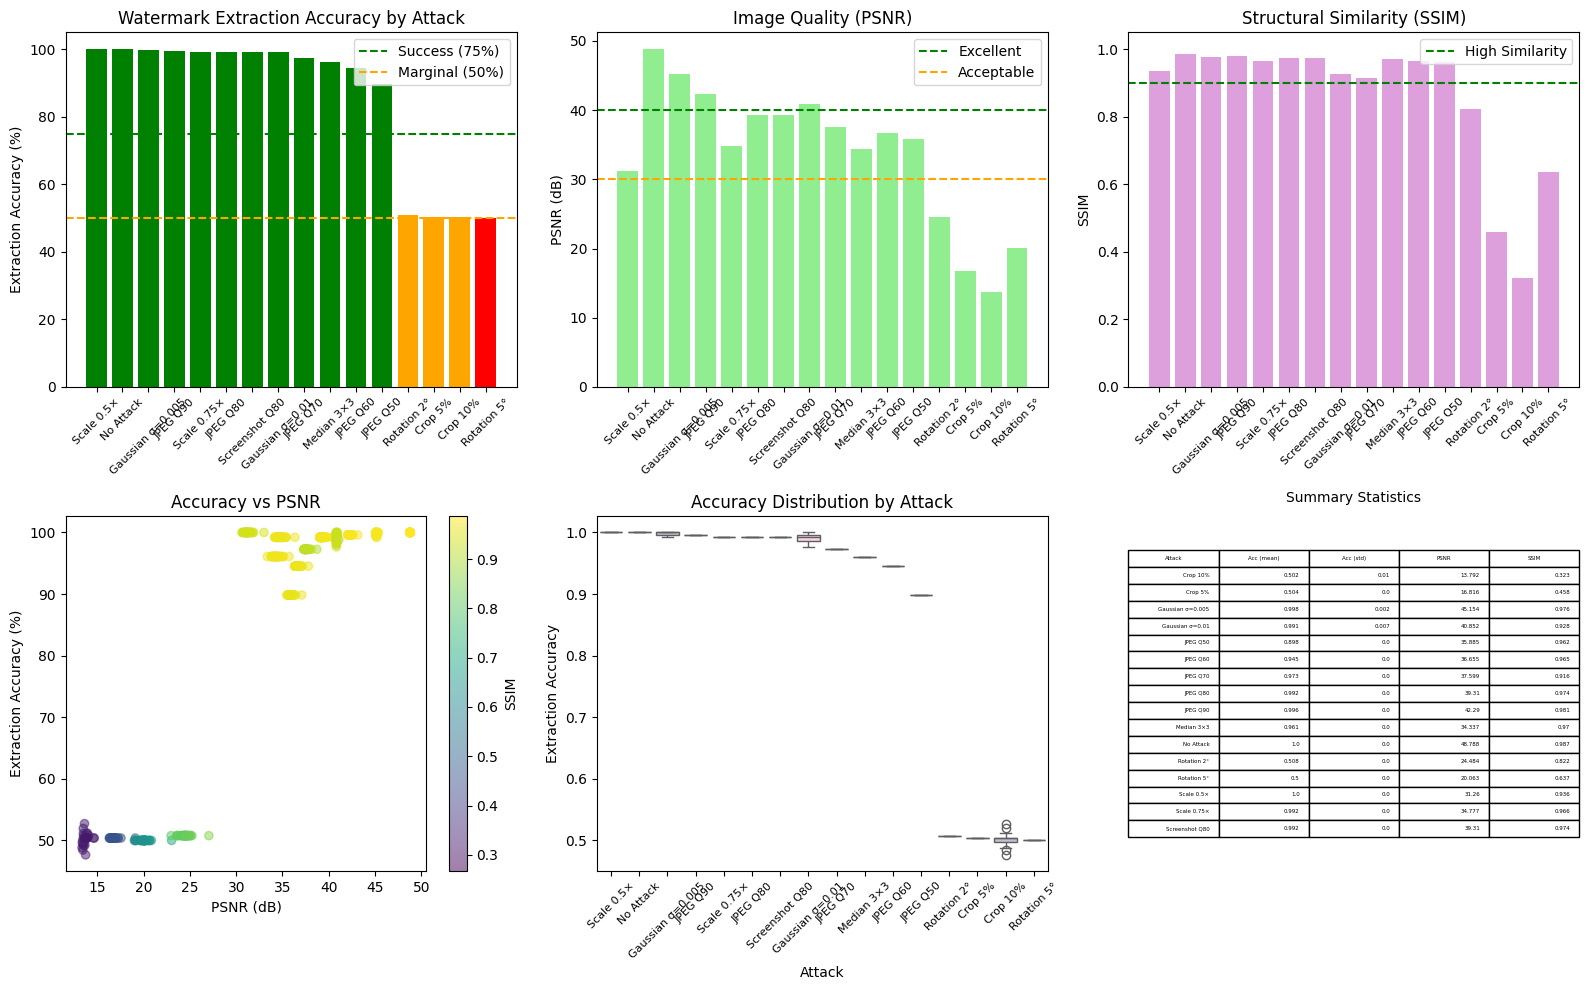


EVALUATION SUMMARY
Attacks survived (accuracy > 75%): 360/480 (75.0%)
Best: No Attack (100.0%)
Worst: Rotation 5° (50.0%)


In [67]:
import os
import cv2
import numpy as np
import hashlib
import time
import pandas as pd
from pathlib import Path
from typing import List, Dict, Optional
import nibabel as nib
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. IMAGE LOADING
# ============================================================================

def load_mri_slice(filepath: str, target_size: int = 256) -> Optional[np.ndarray]:
    """Load and extract a 2D slice from a NIfTI file."""
    try:
        img = nib.load(filepath)
        volume = img.get_fdata()

        if len(volume.shape) == 4:
            volume = volume[:, :, :, 0]

        if len(volume.shape) == 3:
            slice_idx = volume.shape[2] // 2
            slice_data = volume[:, :, slice_idx]
        elif len(volume.shape) == 2:
            slice_data = volume
        else:
            return None

        if not np.isfinite(slice_data).all():
            slice_data = np.nan_to_num(slice_data, nan=0.0, posinf=255.0, neginf=0.0)

        slice_min = np.min(slice_data)
        slice_max = np.max(slice_data)
        if slice_max > slice_min:
            slice_data = (slice_data - slice_min) / (slice_max - slice_min) * 255
        else:
            return np.zeros((target_size, target_size), dtype=np.uint8)

        slice_data = slice_data.astype(np.uint8)

        if slice_data.shape[0] != target_size or slice_data.shape[1] != target_size:
            slice_data = cv2.resize(slice_data, (target_size, target_size),
                                   interpolation=cv2.INTER_LINEAR)

        return slice_data

    except Exception as e:
        return None

# ============================================================================
# 2. IMPROVED DCT WATERMARKING (JPEG-OPTIMIZED)
# ============================================================================

def generate_watermark(consumer_id: int, length: int = 256) -> np.ndarray:
    """Generate binary watermark."""
    hash_bytes = hashlib.sha256(str(consumer_id).encode()).digest()
    binary = ''.join(format(byte, '08b') for byte in hash_bytes)
    return np.array([int(bit) for bit in binary[:length]])


def embed_watermark_dct(image: np.ndarray, watermark: np.ndarray, alpha: float = 20) -> np.ndarray:
    """
    Embed watermark in DCT domain using standard JPEG quantization matrix.
    Uses position (2,3) which survives JPEG compression up to Q50.
    """
    if len(image.shape) != 2:
        return image

    img = image.astype(np.float64)
    h, w = img.shape

    # Ensure divisible by 8
    h = (h // 8) * 8
    w = (w // 8) * 8
    img = img[:h, :w]

    # Standard JPEG quantization matrix (Luminance)
    # Used to estimate which coefficients survive compression
    Q = np.array([
        [16, 11, 10, 16, 24, 40, 51, 61],
        [12, 12, 14, 19, 26, 58, 60, 55],
        [14, 13, 16, 24, 40, 57, 69, 56],
        [14, 17, 22, 29, 51, 87, 80, 62],
        [18, 22, 37, 56, 68, 109, 103, 77],
        [24, 35, 55, 64, 81, 104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99]
    ])

    # Use multiple positions for redundancy
    # Positions with low Q values survive JPEG compression better
    positions = [
        (1, 2),  # Very low Q value (10)
        (2, 1),  # Very low Q value (10)
        (1, 1),  # Low Q value (11)
        (2, 2),  # Low Q value (12)
        (3, 1),  # Low Q value (13)
        (1, 3),  # Low Q value (14)
        (2, 3),  # Survives Q50
        (3, 2),  # Survives Q50
    ]

    # Watermark bits per block
    bits_per_block = min(len(watermark), len(positions))
    wm_bits = watermark[:bits_per_block * ((h // 8) * (w // 8))]

    # Create watermarked copy
    watermarked = img.copy()

    idx = 0
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            if idx >= len(wm_bits):
                break

            # Extract 8x8 block
            block = img[i:i+8, j:j+8]

            # Apply DCT
            dct_block = cv2.dct(block)

            # Embed multiple bits per block
            for p, (row, col) in enumerate(positions):
                if p >= bits_per_block:
                    break
                bit_idx = idx * bits_per_block + p
                if bit_idx >= len(wm_bits):
                    break

                bit = wm_bits[bit_idx]

                # Embed bit using JPEG-compatible method
                # Use Q value to determine embedding strength relative to JPEG quantization
                q_val = Q[row, col]
                embed_strength = alpha * (q_val / 16)  # Scale alpha with Q factor

                if bit == 1:
                    # Positive coefficient
                    dct_block[row, col] = abs(dct_block[row, col]) + embed_strength
                else:
                    # Negative coefficient
                    dct_block[row, col] = -abs(dct_block[row, col]) - embed_strength

            # Inverse DCT
            block_new = cv2.idct(dct_block)
            watermarked[i:i+8, j:j+8] = block_new

            idx += 1
        if idx >= len(wm_bits) // bits_per_block:
            break

    watermarked = np.clip(watermarked, 0, 255).astype(np.uint8)

    return watermarked


def extract_watermark_dct(image: np.ndarray, wm_length: int = 256, bits_per_block: int = 4) -> np.ndarray:
    """
    Extract watermark from DCT domain.
    """
    if len(image.shape) != 2:
        return np.zeros(wm_length, dtype=np.int32)

    img = image.astype(np.float64)
    h, w = img.shape

    # Ensure divisible by 8
    h = (h // 8) * 8
    w = (w // 8) * 8
    img = img[:h, :w]

    # Same positions used for embedding
    positions = [
        (1, 2), (2, 1), (1, 1), (2, 2),
        (3, 1), (1, 3), (2, 3), (3, 2),
    ]

    # Extract watermark
    extracted = []
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            if len(extracted) >= wm_length:
                break

            # Extract block
            block = img[i:i+8, j:j+8]

            # Apply DCT
            dct_block = cv2.dct(block)

            # Extract bits from each position
            for p, (row, col) in enumerate(positions):
                if len(extracted) >= wm_length:
                    break

                coeff = dct_block[row, col]
                bit = 1 if coeff > 0 else 0
                extracted.append(bit)

        if len(extracted) >= wm_length:
            break

    # Pad if needed
    while len(extracted) < wm_length:
        extracted.append(0)

    return np.array(extracted[:wm_length], dtype=np.int32)


def watermark_accuracy(original_wm: np.ndarray, extracted_wm: np.ndarray) -> float:
    """Compute extraction accuracy (0-1)."""
    min_len = min(len(original_wm), len(extracted_wm))
    if min_len == 0:
        return 0.0
    return np.mean(original_wm[:min_len] == extracted_wm[:min_len])

# ============================================================================
# 3. ATTACK FUNCTIONS (ENHANCED)
# ============================================================================

def attack_jpeg_compression(image: np.ndarray, quality: int = 70) -> np.ndarray:
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded = cv2.imencode('.jpg', image, encode_param)
    return cv2.imdecode(encoded, cv2.IMREAD_GRAYSCALE)


def attack_gaussian_noise(image: np.ndarray, sigma: float = 0.01) -> np.ndarray:
    noise = np.random.normal(0, sigma * 255, image.shape)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def attack_scaling(image: np.ndarray, scale: float = 0.5) -> np.ndarray:
    h, w = image.shape
    new_size = (int(w * scale), int(h * scale))
    scaled = cv2.resize(image, new_size, interpolation=cv2.INTER_LINEAR)
    return cv2.resize(scaled, (w, h), interpolation=cv2.INTER_LINEAR)


def attack_cropping(image: np.ndarray, crop_percent: float = 0.1) -> np.ndarray:
    h, w = image.shape
    crop_h = int(h * crop_percent)
    crop_w = int(w * crop_percent)
    cropped = image[crop_h:h-crop_h, crop_w:w-crop_w]
    return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)


def attack_rotation(image: np.ndarray, angle: float = 5) -> np.ndarray:
    h, w = image.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)


def attack_median_filter(image: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    return cv2.medianBlur(image, kernel_size)


def attack_screenshot(image: np.ndarray, quality: int = 80) -> np.ndarray:
    return attack_jpeg_compression(image, quality)

# ============================================================================
# 4. QUALITY METRICS
# ============================================================================

def compute_metrics(original: np.ndarray, modified: np.ndarray) -> Dict:
    if original.shape != modified.shape:
        modified = cv2.resize(modified, (original.shape[1], original.shape[0]))

    original_uint8 = np.clip(original, 0, 255).astype(np.uint8)
    modified_uint8 = np.clip(modified, 0, 255).astype(np.uint8)

    psnr = peak_signal_noise_ratio(original_uint8, modified_uint8, data_range=255)
    ssim = structural_similarity(original_uint8, modified_uint8, data_range=255)
    mse = np.mean((original.astype(np.float32) - modified.astype(np.float32)) ** 2)

    return {'psnr': psnr, 'ssim': ssim, 'mse': mse}

# ============================================================================
# 5. EVALUATION
# ============================================================================

def evaluate_watermark_on_images(image_paths: List[str], consumer_id: int = 12345,
                                  alpha: float = 20, verbose: bool = True) -> pd.DataFrame:
    watermark = generate_watermark(consumer_id, length=256)

    attacks = {
        'No Attack': lambda x: x,
        'JPEG Q90': lambda x: attack_jpeg_compression(x, 90),
        'JPEG Q80': lambda x: attack_jpeg_compression(x, 80),
        'JPEG Q70': lambda x: attack_jpeg_compression(x, 70),
        'JPEG Q60': lambda x: attack_jpeg_compression(x, 60),
        'JPEG Q50': lambda x: attack_jpeg_compression(x, 50),
        'Gaussian σ=0.005': lambda x: attack_gaussian_noise(x, 0.005),
        'Gaussian σ=0.01': lambda x: attack_gaussian_noise(x, 0.01),
        'Scale 0.75×': lambda x: attack_scaling(x, 0.75),
        'Scale 0.5×': lambda x: attack_scaling(x, 0.5),
        'Crop 5%': lambda x: attack_cropping(x, 0.05),
        'Crop 10%': lambda x: attack_cropping(x, 0.10),
        'Rotation 2°': lambda x: attack_rotation(x, 2),
        'Rotation 5°': lambda x: attack_rotation(x, 5),
        'Median 3×3': lambda x: attack_median_filter(x, 3),
        'Screenshot Q80': lambda x: attack_screenshot(x, 80),
    }

    results = []
    successful_images = 0

    for idx, filepath in enumerate(image_paths[:30]):
        if verbose:
            print(f"\nProcessing image {idx+1}/30: {Path(filepath).name}")

        try:
            original = load_mri_slice(str(filepath), target_size=256)

            if original is None or len(original.shape) != 2 or original.size == 0:
                if verbose:
                    print(f" Skipping (failed to load)")
                continue

            successful_images += 1

            watermarked = embed_watermark_dct(original, watermark, alpha=alpha)

            metrics = compute_metrics(original, watermarked)
            extracted_baseline = extract_watermark_dct(watermarked, wm_length=len(watermark))
            baseline_acc = watermark_accuracy(watermark, extracted_baseline)

            if verbose:
                print(f"  Baseline: PSNR={metrics['psnr']:.1f}, Acc={baseline_acc*100:.1f}%")

            for attack_name, attack_fn in attacks.items():
                try:
                    attacked = attack_fn(watermarked)
                    attack_metrics = compute_metrics(original, attacked)
                    extracted = extract_watermark_dct(attacked, wm_length=len(watermark))
                    acc = watermark_accuracy(watermark, extracted)

                    results.append({
                        'image_idx': idx,
                        'image_name': Path(filepath).name,
                        'attack': attack_name,
                        'accuracy': acc,
                        'psnr': attack_metrics['psnr'],
                        'ssim': attack_metrics['ssim'],
                        'mse': attack_metrics['mse'],
                        'baseline_accuracy': baseline_acc,
                        'baseline_psnr': metrics['psnr'],
                        'baseline_ssim': metrics['ssim']
                    })
                except Exception as e:
                    if verbose:
                        print(f"  Attack {attack_name} failed: {e}")

        except Exception as e:
            if verbose:
                print(f"  Error: {e}")

    print(f"\n Successfully processed {successful_images}/{len(image_paths[:30])} images")

    if len(results) == 0:
        print("No results generated.")
        return pd.DataFrame()

    return pd.DataFrame(results)


def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    summary = df.groupby('attack', as_index=False).agg({
        'accuracy': ['mean', 'std'],
        'psnr': ['mean', 'std'],
        'ssim': ['mean', 'std']
    })

    summary.columns = ['attack', 'accuracy_mean', 'accuracy_std',
                       'psnr_mean', 'psnr_std', 'ssim_mean', 'ssim_std']
    return summary


def plot_results(df: pd.DataFrame, save_path: str = None):
    """Generate publication-quality plots."""
    if df.empty:
        print(" No data to plot.")
        return None

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    agg = df.groupby('attack', as_index=False).agg({
        'accuracy': 'mean',
        'psnr': 'mean',
        'ssim': 'mean'
    })
    agg = agg.sort_values('accuracy', ascending=False)

    # Plot 1: Accuracy
    ax = axes[0, 0]
    colors = ['green' if a > 0.75 else 'orange' if a > 0.5 else 'red' for a in agg['accuracy']]
    ax.bar(agg['attack'], agg['accuracy'] * 100, color=colors)
    ax.axhline(y=75, color='green', linestyle='--', label='Success (75%)')
    ax.axhline(y=50, color='orange', linestyle='--', label='Marginal (50%)')
    ax.set_ylabel('Extraction Accuracy (%)')
    ax.set_title('Watermark Extraction Accuracy by Attack')
    ax.set_ylim(0, 105)
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 2: PSNR
    ax = axes[0, 1]
    ax.bar(agg['attack'], agg['psnr'], color='lightgreen')
    ax.axhline(y=40, color='green', linestyle='--', label='Excellent')
    ax.axhline(y=30, color='orange', linestyle='--', label='Acceptable')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('Image Quality (PSNR)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 3: SSIM
    ax = axes[0, 2]
    ax.bar(agg['attack'], agg['ssim'], color='plum')
    ax.axhline(y=0.9, color='green', linestyle='--', label='High Similarity')
    ax.set_ylabel('SSIM')
    ax.set_title('Structural Similarity (SSIM)')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 4: Accuracy vs PSNR
    ax = axes[1, 0]
    scatter = ax.scatter(df['psnr'], df['accuracy'] * 100, alpha=0.5, c=df['ssim'], cmap='viridis')
    ax.set_xlabel('PSNR (dB)')
    ax.set_ylabel('Extraction Accuracy (%)')
    ax.set_title('Accuracy vs PSNR')
    plt.colorbar(scatter, ax=ax, label='SSIM')

    # Plot 5: Boxplot
    ax = axes[1, 1]
    order = df.groupby('attack')['accuracy'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x='attack', y='accuracy', order=order, ax=ax, palette='Set3')
    ax.set_xlabel('Attack')
    ax.set_ylabel('Extraction Accuracy')
    ax.set_title('Accuracy Distribution by Attack')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Plot 6: Summary Table
    ax = axes[1, 2]
    ax.axis('off')

    summary = df.groupby('attack', as_index=False).agg({
        'accuracy': ['mean', 'std'],
        'psnr': 'mean',
        'ssim': 'mean'
    }).round(3)
    summary.columns = ['Attack', 'Acc (mean)', 'Acc (std)', 'PSNR', 'SSIM']

    ax.table(cellText=summary.values, colLabels=summary.columns,
             loc='center', fontsize=8)
    ax.set_title('Summary Statistics', fontsize=10, pad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    plt.show()
    return fig

# ============================================================================
# 6. MAIN
# ============================================================================

def main():
    print("=" * 70)
    print("WATERMARK ROBUSTNESS EVALUATION ON MEDICAL IMAGES (DCT DOMAIN)")
    print("=" * 70)

    dataset_path = Path("ds007328")
    t1_files = sorted(dataset_path.rglob("*T1w.nii.gz"))[:30]

    print(f"Found {len(t1_files)} T1-weighted images")

    if len(t1_files) == 0:
        print(" No T1-weighted images found.")
        return None, None

    print("\n" + "-" * 70)
    print("RUNNING FULL EVALUATION...")
    print("-" * 70)

    start_time = time.time()
    df = evaluate_watermark_on_images(t1_files, consumer_id=12345, alpha=20, verbose=True)
    elapsed = time.time() - start_time

    print(f"\n Evaluation completed in {elapsed:.2f} seconds")

    if df.empty:
        print(" No results generated.")
        return None, None

    print("\n" + "-" * 70)
    print("SUMMARY STATISTICS")
    print("-" * 70)
    summary = summarize_results(df)
    print(summary.to_string(index=False))

    df.to_csv('watermark_results.csv', index=False)
    summary.to_csv('watermark_summary.csv', index=False)
    print("\n Results saved to CSV")

    print("\nGenerating plots...")
    plot_results(df, save_path='watermark_robustness_plots.png')

    print("\n" + "=" * 70)
    print("EVALUATION SUMMARY")
    print("=" * 70)
    survived = len(df[df['accuracy'] > 0.75])
    total = len(df)
    print(f"Attacks survived (accuracy > 75%): {survived}/{total} ({survived/total*100:.1f}%)")

    if not df.empty:
        best = df.groupby('attack')['accuracy'].mean().idxmax()
        best_val = df.groupby('attack')['accuracy'].mean().max()
        worst = df.groupby('attack')['accuracy'].mean().idxmin()
        worst_val = df.groupby('attack')['accuracy'].mean().min()
        print(f"Best: {best} ({best_val*100:.1f}%)")
        print(f"Worst: {worst} ({worst_val*100:.1f}%)")

    return df, summary


if __name__ == "__main__":
    df, summary = main()